In [1]:
# 1. Установка библиотек и импорт модулей
!pip install catboost xgboost optuna --quiet

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Conv1D, Dense, SpatialDropout1D, Softmax, Multiply, Lambda, LSTM
from tensorflow.keras.callbacks import EarlyStopping
import optuna
import json
import matplotlib.pyplot as plt

# Фиксируем зерно для воспроизводимости
np.random.seed(42)
tf.random.set_seed(42)

# Загрузка данных (например, 'data_fragment.csv' или другой файл CSV)
df = pd.read_csv('data.csv', sep=';', decimal=',', parse_dates=['Datetime'], dayfirst=True, encoding='cp1251')
# Убираем пустые строки (если остались после чтения)
df = df[df['Datetime'].notna()]

# Переименование столбцов для удобства
df.columns = ['Datetime', 'Radon', 'Temperature', 'Pressure']

# Сортировка по времени и сброс индексов
df.sort_values('Datetime', inplace=True)
df.reset_index(drop=True, inplace=True)

# Проверка пропусков до обработки
print("Всего записей:", len(df))
print("Пропущенных значений до обработки:\n", df.isna().sum())

# Обработка пропусков: установка Datetime как индекс и преобразование его в DatetimeIndex
if not isinstance(df.index, pd.DatetimeIndex):
    df.set_index(df['Datetime'], inplace=True)

# Линейная интерполяция по времени
for col in ['Radon','Temperature','Pressure']:
    df[col] = df[col].interpolate(method='time')
    df[col] = df[col].fillna(method='bfill').fillna(method='ffill')

# Возвращаем индекс в колонку
df.reset_index(drop=True, inplace=True)

print("Пропущенных значений после обработки:\n", df.isna().sum())

# Обработка выбросов (ограничение значений по IQR)
for col in ['Radon','Temperature','Pressure']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

print("Диапазон значений после удаления выбросов:")
print(df[['Radon','Temperature','Pressure']].describe().loc[['min','max']])

# Генерация дополнительных признаков: градиенты, скользящие средние, календарные признаки
df['radon_diff1']  = df['Radon'].diff(periods=1)    # изменение за 1 шаг
df['radon_diff17'] = df['Radon'].diff(periods=17)   # изменение за ≈сутки (17 шагов ~24ч)
df['radon_ma3']   = df['Radon'].rolling(window=3).mean()
df['radon_ma6']   = df['Radon'].rolling(window=6).mean()
df['radon_ma17']  = df['Radon'].rolling(window=17).mean()
df['radon_ma34']  = df['Radon'].rolling(window=34).mean()
df['month'] = pd.to_datetime(df['Datetime'], dayfirst=True).dt.month
df['hour']  = pd.to_datetime(df['Datetime'], dayfirst=True).dt.hour
df['day_of_week'] = pd.to_datetime(df['Datetime'], dayfirst=True).dt.weekday

# Заполнение NaN, возникших после diff/rolling
df.fillna(method='bfill', inplace=True)

print("Сгенерированные признаки. Колонки датасета:", df.columns.tolist())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 10.1 MB/s eta 0:00:00
Всего записей: 8762
Пропущенных значений до обработки:
 Datetime        0
Radon           9
Temperature    55
Pressure        0
dtype: int64
Пропущенных значений после обработки:
 Datetime       0
Radon          0
Temperature    0
Pressure       0
dtype: int64
Диапазон значений после удаления выбросов:
       Radon  Temperature     Pressure
min    508.0    -1.354161   958.782100
max  38533.0     8.338097  1011.087849
Сгенерированные признаки. Колонки датасета: ['Datetime', 'Radon', 'Temperature', 'Pressure', 'radon_diff1', 'radon_diff17', 'radon_ma3', 'radon_ma6', 'radon_ma17', 'radon_ma34', 'month', 'hour', 'day_of_week']


<ipython-input-1-f01be511d66e>:45: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[col] = df[col].fillna(method='bfill').fillna(method='ffill')
<ipython-input-1-f01be511d66e>:45: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[col] = df[col].fillna(method='bfill').fillna(method='ffill')
<ipython-input-1-f01be511d66e>:45: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[col] = df[col].fillna(method='bfill').fillna(method='ffill')
<ipython-input-1-f01be511d66e>:76: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


In [2]:
# 2. Формирование обучающих, валидационных и тестовых наборов
# Задаём горизонт прогноза и длину истории
HORIZON = 51    # прогноз на 51 шаг (~3 дня)
SEQ_LENGTH = 68 # история длиной 68 шагов (~4 суток)

total_points = len(df)
start_index = HORIZON + SEQ_LENGTH - 1
if start_index >= total_points:
    # Если недостаточно данных, уменьшаем длину последовательности
    SEQ_LENGTH = total_points - HORIZON
    start_index = HORIZON + SEQ_LENGTH - 1
    if start_index >= total_points or SEQ_LENGTH <= 0:
        raise ValueError("Недостаточно данных для выбранных HORIZON и SEQ_LENGTH.")
print(f"Используем SEQ_LENGTH={SEQ_LENGTH}, HORIZON={HORIZON}")

target_indices = list(range(start_index, total_points))
print(f"Всего примеров после учёта горизонта и истории: {len(target_indices)}")

# Разбиваем индексы на train/val/test (70%/15%/15%)
train_size = int(0.70 * len(target_indices))
val_size   = int(0.15 * len(target_indices))
test_size  = len(target_indices) - train_size - val_size

train_idx = target_indices[:train_size]
val_idx   = target_indices[train_size: train_size + val_size]
test_idx  = target_indices[train_size + val_size:]
print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

# Признаки для табличных моделей (CatBoost, XGBoost)
tab_features = [
    'Radon','Temperature','Pressure',
    'radon_diff1','radon_diff17',
    'radon_ma3','radon_ma6','radon_ma17','radon_ma34',
    'month','hour','day_of_week'
]

# Списки для хранения выборок
X_train_tab, X_val_tab, X_test_tab = [], [], []
X_train_seq, X_val_seq, X_test_seq = [], [], []
y_train, y_val, y_test = [], [], []

# Формируем данные
for idx_list, X_tab_list, X_seq_list, y_list in [
    (train_idx, X_train_tab, X_train_seq, y_train),
    (val_idx,   X_val_tab,   X_val_seq,   y_val),
    (test_idx,  X_test_tab,  X_test_seq,  y_test)
]:
    for j in idx_list:
        i = j - HORIZON
        # Табличные признаки на момент i
        X_tab_list.append(df.loc[i, tab_features].values.astype(float))
        # Последовательность (Radon, Temperature, Pressure) от i-SEQ_LENGTH+1 до i
        seq_start = i - SEQ_LENGTH + 1
        seq_vals = df.loc[seq_start:i, ['Radon','Temperature','Pressure']].values.astype(float)
        X_seq_list.append(seq_vals)
        # Целевое значение: Radon на момент j
        y_list.append(df.loc[j, 'Radon'])

# Преобразуем в массивы
X_train_tab = np.array(X_train_tab); X_val_tab = np.array(X_val_tab); X_test_tab = np.array(X_test_tab)
X_train_seq = np.array(X_train_seq); X_val_seq = np.array(X_val_seq); X_test_seq = np.array(X_test_seq)
y_train = np.array(y_train); y_val = np.array(y_val); y_test = np.array(y_test)

print("Размеры выборок:")
print("X_train_tab:", X_train_tab.shape, "| X_train_seq:", X_train_seq.shape, "| y_train:", y_train.shape)
print("X_val_tab:  ", X_val_tab.shape,   "| X_val_seq:  ", X_val_seq.shape,   "| y_val:  ", y_val.shape)
print("X_test_tab: ", X_test_tab.shape,  "| X_test_seq: ", X_test_seq.shape,  "| y_test: ", y_test.shape)

# Масштабируем входные временные последовательности (StandardScaler)
scaler = StandardScaler()
X_train_seq_flat = X_train_seq.reshape(-1, X_train_seq.shape[-1])
scaler.fit(X_train_seq_flat)
X_train_seq = scaler.transform(X_train_seq_flat).reshape(X_train_seq.shape)
X_val_seq   = scaler.transform(X_val_seq.reshape(-1, X_val_seq.shape[-1])).reshape(X_val_seq.shape)
X_test_seq  = scaler.transform(X_test_seq.reshape(-1, X_test_seq.shape[-1])).reshape(X_test_seq.shape)
print("Масштабирование последовательностей выполнено.")


Используем SEQ_LENGTH=68, HORIZON=51
Всего примеров после учёта горизонта и истории: 8644
Train: 6050, Val: 1296, Test: 1298
Размеры выборок:
X_train_tab: (6050, 12) | X_train_seq: (6050, 68, 3) | y_train: (6050,)
X_val_tab:   (1296, 12) | X_val_seq:   (1296, 68, 3) | y_val:   (1296,)
X_test_tab:  (1298, 12) | X_test_seq:  (1298, 68, 3) | y_test:  (1298,)
Масштабирование последовательностей выполнено.


In [3]:
# 3. Оптимизация гиперпараметров CatBoost и XGBoost с помощью Optuna

from sklearn.metrics import mean_squared_error
import numpy as np

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse'
    }
    model = XGBRegressor(**params)
    model.fit(X_train_tab, y_train, eval_set=[(X_val_tab, y_val)], verbose=False)
    preds = model.predict(X_val_tab)
    return np.sqrt(mean_squared_error(y_val, preds))  # RMSE

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=20)
best_xgb_params = study_xgb.best_params
print("Лучшие параметры XGBoost:", best_xgb_params)

def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'depth': trial.suggest_int('depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'random_seed': 42,
        'verbose': False
    }
    model = CatBoostRegressor(**params)
    model.fit(X_train_tab, y_train, eval_set=(X_val_tab, y_val),
              early_stopping_rounds=20, verbose=False)
    preds = model.predict(X_val_tab)
    return np.sqrt(mean_squared_error(y_val, preds))

study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=20)
best_cat_params = study_cat.best_params
print("Лучшие параметры CatBoost:", best_cat_params)


[I 2025-05-09 12:40:01,078] A new study created in memory with name: no-name-5a9fac8f-13f7-4bc2-9da7-07d003fbf8d3
[I 2025-05-09 12:40:31,094] Trial 0 finished with value: 6810.085518810595 and parameters: {'n_estimators': 482, 'max_depth': 8, 'learning_rate': 0.09338839896421236, 'subsample': 0.680651487066112, 'colsample_bytree': 0.8951915190076696}. Best is trial 0 with value: 6810.085518810595.
[I 2025-05-09 12:40:31,647] Trial 1 finished with value: 7431.084162547055 and parameters: {'n_estimators': 103, 'max_depth': 7, 'learning_rate': 0.29911232944362065, 'subsample': 0.8538175505279408, 'colsample_bytree': 0.8357706414391813}. Best is trial 0 with value: 6810.085518810595.
[I 2025-05-09 12:40:34,488] Trial 2 finished with value: 7262.946271849205 and parameters: {'n_estimators': 179, 'max_depth': 10, 'learning_rate': 0.23909401415724146, 'subsample': 0.6972652841440907, 'colsample_bytree': 0.8741812429676684}. Best is trial 0 with value: 6810.085518810595.
[I 2025-05-09 12:40:36

Лучшие параметры XGBoost: {'n_estimators': 494, 'max_depth': 9, 'learning_rate': 0.011043878925052463, 'subsample': 0.9941716609073645, 'colsample_bytree': 0.611141855149474}


[I 2025-05-09 12:41:20,370] Trial 0 finished with value: 6238.054120764621 and parameters: {'iterations': 342, 'depth': 8, 'learning_rate': 0.1331299728004929}. Best is trial 0 with value: 6238.054120764621.
[I 2025-05-09 12:41:20,916] Trial 1 finished with value: 6247.790124956416 and parameters: {'iterations': 249, 'depth': 8, 'learning_rate': 0.0393954313936277}. Best is trial 0 with value: 6238.054120764621.
[I 2025-05-09 12:41:21,277] Trial 2 finished with value: 6219.339212798848 and parameters: {'iterations': 424, 'depth': 8, 'learning_rate': 0.08644665935671174}. Best is trial 2 with value: 6219.339212798848.
[I 2025-05-09 12:41:21,512] Trial 3 finished with value: 6295.440879248102 and parameters: {'iterations': 180, 'depth': 7, 'learning_rate': 0.19506907275982185}. Best is trial 2 with value: 6219.339212798848.
[I 2025-05-09 12:41:21,683] Trial 4 finished with value: 5988.684595570708 and parameters: {'iterations': 304, 'depth': 3, 'learning_rate': 0.041210076196294444}. Bes

Лучшие параметры CatBoost: {'iterations': 449, 'depth': 3, 'learning_rate': 0.1263012684734241}


In [4]:
# 4. Обучение моделей градиентного бустинга

# XGBoost
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42, **best_xgb_params)
xgb_model.fit(X_train_tab, y_train, eval_set=[(X_val_tab, y_val)], verbose=False)

print("XGBoost обучен. Использовано деревьев:", best_xgb_params['n_estimators'])

# CatBoost
cat_model = CatBoostRegressor(loss_function='RMSE', random_seed=42, **best_cat_params)
cat_model.fit(X_train_tab, y_train, eval_set=(X_val_tab, y_val),
              early_stopping_rounds=50, verbose=False)
print("CatBoost обучен. Использовано деревьев:", cat_model.tree_count_)

# 5. Обучение нейросетевых моделей

# 5.1 1D-CNN с механизмом внимания
sequence_input = Input(shape=(SEQ_LENGTH, 3), name='cnn_input')
x = Conv1D(filters=64, kernel_size=3, padding='same', activation='relu')(sequence_input)
x = SpatialDropout1D(0.2)(x)
score = Dense(1, activation=None)(x)
attention_weights = Softmax(axis=1)(score)
weighted_seq = Multiply()([x, attention_weights])
context_vector = Lambda(lambda z: tf.reduce_sum(z, axis=1))(weighted_seq)
dense_out = Dense(32, activation='relu')(context_vector)
cnn_output = Dense(1, activation='linear')(dense_out)
cnn_model = Model(inputs=sequence_input, outputs=cnn_output)
cnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
cnn_model.summary()

early_stop_cnn = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history_cnn = cnn_model.fit(X_train_seq, y_train,
                            epochs=50, batch_size=16,
                            validation_data=(X_val_seq, y_val),
                            callbacks=[early_stop_cnn], verbose=0)
print("CNN+Attention обучена, эпох выполнено:", len(history_cnn.history['loss']))

# 5.2 LSTM с механизмом внимания
lstm_input = Input(shape=(SEQ_LENGTH, 3), name='lstm_input')
lstm_out = LSTM(64, activation='tanh', return_sequences=True, dropout=0.2)(lstm_input)
score_seq = Dense(1, activation=None)(lstm_out)
attention_weights2 = Softmax(axis=1)(score_seq)
context_vector2 = Multiply()([lstm_out, attention_weights2])
context_vector2 = Lambda(lambda z: tf.reduce_sum(z, axis=1))(context_vector2)
dense_layer = Dense(32, activation='relu')(context_vector2)
lstm_output = Dense(1, activation='linear')(dense_layer)
lstm_model = Model(inputs=lstm_input, outputs=lstm_output)
lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

early_stop_lstm = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history_lstm = lstm_model.fit(X_train_seq, y_train,
                              epochs=50, batch_size=16,
                              validation_data=(X_val_seq, y_val),
                              callbacks=[early_stop_lstm], verbose=0)
print("LSTM+Attention обучена, эпох выполнено:", len(history_lstm.history['loss']))


XGBoost обучен. Использовано деревьев: 494
CatBoost обучен. Использовано деревьев: 9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cnn_input           │ (None, 68, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 68, 64)    │        640 │ cnn_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 68, 64)    │          0 │ conv1d[0][0]      │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 68, 1)     │         65 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 68, 1)     │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 68, 64)    │          0 │ spatial_dropout1… │
│                     │                   │            │ softmax[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 64)        │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,818 (11.01 KB)

 Trainable params: 2,818 (11.01 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ lstm_input          │ (None, 68, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 68, 64)    │     17,408 │ lstm_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 68, 1)     │         65 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_1 (Softmax) │ (None, 68, 1)     │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 68, 64)    │          0 │ lstm[0][0],       │
│ (Multiply)          │                   │            │ softmax_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 64)        │          0 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         33 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,586 (76.51 KB)

 Trainable params: 19,586 (76.51 KB)

 Non-trainable params: 0 (0.00 B)

LSTM+Attention обучена, эпох выполнено: 19


In [5]:
# 6. Стеккинг: обучение метамодели на предсказаниях базовых моделей

# Предсказания на валидации
val_preds_xgb = xgb_model.predict(X_val_tab)
val_preds_cat = cat_model.predict(X_val_tab)
val_preds_cnn = cnn_model.predict(X_val_seq).reshape(-1)
val_preds_lstm = lstm_model.predict(X_val_seq).reshape(-1)

# Формируем обучающую матрицу для метамодели
X_meta_train = np.column_stack([val_preds_xgb, val_preds_cat, val_preds_cnn, val_preds_lstm])
y_meta_train = y_val

meta_model = Sequential()
meta_model.add(Dense(4, activation='relu', input_shape=(4,)))  # 4 входа – по одному от каждой модели
meta_model.add(Dense(1, activation='linear'))
meta_model.compile(optimizer='adam', loss='mse')
meta_model.fit(X_meta_train, y_meta_train, epochs=20, batch_size=8, verbose=0)
print("Метамодель стеккинга обучена.")

# 7. Оценка финальной метамодели на тесте

# Предсказания базовых моделей на тесте
test_preds_xgb = xgb_model.predict(X_test_tab)
test_preds_cat = cat_model.predict(X_test_tab)
test_preds_cnn = cnn_model.predict(X_test_seq).reshape(-1)
test_preds_lstm = lstm_model.predict(X_test_seq).reshape(-1)

# Финальный прогноз метамодели (стеккинг)
X_meta_test = np.column_stack([test_preds_xgb, test_preds_cat, test_preds_cnn, test_preds_lstm])
final_preds = meta_model.predict(X_meta_test).reshape(-1)

# Вычисление метрик качества
mae_value = mean_absolute_error(y_test, final_preds)
rmse_value = np.sqrt(mean_squared_error(y_test, final_preds))
r2_value = r2_score(y_test, final_preds)

print(f"MAE на тесте: {mae_value:.2f}")
print(f"RMSE на тесте: {rmse_value:.2f}")
print(f"R^2 на тесте: {r2_value:.3f}")

# Сохранение финальной модели и метрик
meta_model.save('final_model.h5')
metrics = {"mae": mae_value, "rmse": rmse_value, "r2": r2_value}
with open('metrics.json', 'w') as f:
    json.dump(metrics, f)
print("Итоговая модель и метрики сохранены (final_model.h5, metrics.json).")


41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Метамодель стеккинга обучена.
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


MAE на тесте: 17260.15
RMSE на тесте: 19523.67
R^2 на тесте: -3.578
Итоговая модель и метрики сохранены (final_model.h5, metrics.json).


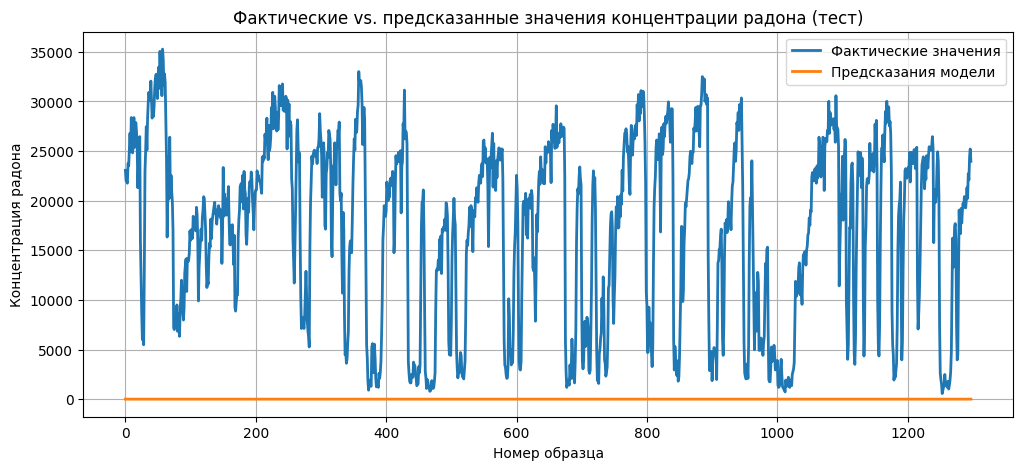

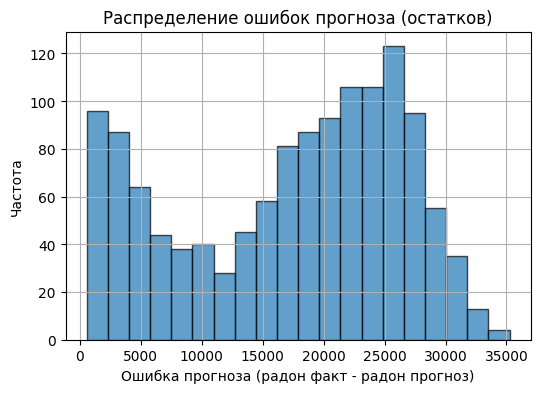

In [6]:
# 8. Графики фактических значений и ошибок прогноза

plt.figure(figsize=(12,5))
plt.plot(y_test, label='Фактические значения', linewidth=2)
plt.plot(final_preds, label='Предсказания модели', linewidth=2)
plt.title('Фактические vs. предсказанные значения концентрации радона (тест)')
plt.xlabel('Номер образца')
plt.ylabel('Концентрация радона')
plt.legend()
plt.grid(True)
plt.show()

residuals = y_test - final_preds
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=20, edgecolor='k', alpha=0.7)
plt.title('Распределение ошибок прогноза (остатков)')
plt.xlabel('Ошибка прогноза (радон факт - радон прогноз)')
plt.ylabel('Частота')
plt.grid(True)
plt.show()
